<a href="https://colab.research.google.com/github/jess22jess/EDPII/blob/main/Prueba_de_frecuencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prueba de Frecuencias
Esta prueba se utiliza principalmente para verificar si los números generados por un generador congruencial se distribuyen de manera uniforme en el intervalo [0,1].

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tabulate import tabulate

Esta es la lista de datos

In [21]:
lista = [
0.78961, 0.05230, 0.10699, 0.55877, 0.14151,
0.76086, 0.12079, 0.27738, 0.65726, 0.79269,
0.80548, 0.82654, 0.29453, 0.20852, 0.42989,
0.58518, 0.98611, 0.34488, 0.34358, 0.11537,
0.89898, 0.57880, 0.67621, 0.05010, 0.00121,
0.28269, 0.73059, 0.70119, 0.18284, 0.49962,
0.38618, 0.76910, 0.68334, 0.55170, 0.10850,
0.79882, 0.45679, 0.21631, 0.87616, 0.55743,
0.58962, 0.33216, 0.03185, 0.61168, 0.09264,
0.69623, 0.17028, 0.05475, 0.91512, 0.76262,
0.29931, 0.30861, 0.83358, 0.51781, 0.03272,
0.57410, 0.26593, 0.85903, 0.43308, 0.35286,
0.24000, 0.65559, 0.38507, 0.90829, 0.94187,
0.93655, 0.88809, 0.81772, 0.36982, 0.19904,
0.54325, 0.62400, 0.09133, 0.41678, 0.33954,
0.58244, 0.85853, 0.86752, 0.38729, 0.15506,
0.23949, 0.53559, 0.33381, 0.49883, 0.75103,
0.19962, 0.65002, 0.74579, 0.79113, 0.63453,
0.19147, 0.40644, 0.08128, 0.73435, 0.22724,
0.22287, 0.07281, 0.64183, 0.44267, 0.72102
]

Aquí creamos el intevalo de nuestras clases.

right=False: significa que los intervalos son cerrados por la izquierda y abiertos por la derecha, excepto el último.

Y usamos conteos para saber cuántos hay en cada intervalo.

In [22]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
# Clasificar datos en intervalos
indices = np.digitize(lista, bins, right=False)
# Contar cuántos hay en cada intervalo
conteos = [(indices == i).sum() for i in range(1, len(bins))]

Creamos nuestra tabla de frecuencias para hacer nuestro histograma

In [23]:
# Tabla de frecuencias
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
intervalos = ['(0, 0.2]','(0.2, 0.4]','(0.4, 0.6]','(0.6, 0.8]','(0.8, 1.01]' ]
frecesp =[]
for i in range(len(conteos)):
  frecesp.append(20)
estad = []
for i in range(len(conteos)):
  estad.append((conteos[i] - frecesp[i])**2/frecesp[i])

tabla = [[int(i+1),intervalos[i], conteos[i], frecesp[i], estad[i] ] for i in range(len(conteos))]
#Aquí hacemos la suma de cada columna para nada más llamar a la función
suma_conteos = sum(conteos)
suma_frecesp = sum(frecesp)
suma_estad = sum(estad)

# Agregar fila de los totales de cada columna
tabla.append(['', 'SUMA', suma_conteos, suma_frecesp, suma_estad])

print(tabulate(tabla,
               headers=['Intervalo','Intervalos', 'Frecuencia observada', 'Frecuencia Esperada', 'Estadistico'],
               tablefmt='grid', numalign='center'))

+-------------+--------------+------------------------+-----------------------+---------------+
| Intervalo   | Intervalos   |  Frecuencia observada  |  Frecuencia Esperada  |  Estadistico  |
+=============+==============+========================+=======================+===============+
| 1           | (0, 0.2]     |           21           |          20           |     0.05      |
+-------------+--------------+------------------------+-----------------------+---------------+
| 2           | (0.2, 0.4]   |           22           |          20           |      0.2      |
+-------------+--------------+------------------------+-----------------------+---------------+
| 3           | (0.4, 0.6]   |           19           |          20           |     0.05      |
+-------------+--------------+------------------------+-----------------------+---------------+
| 4           | (0.6, 0.8]   |           23           |          20           |     0.45      |
+-------------+--------------+----------

Creamos el histograma de frecuencias, donde la línea punteada roja es la frecuencia esperada. Así podemos comparar más facilmente la diferencia entre la observada y la verdadera.

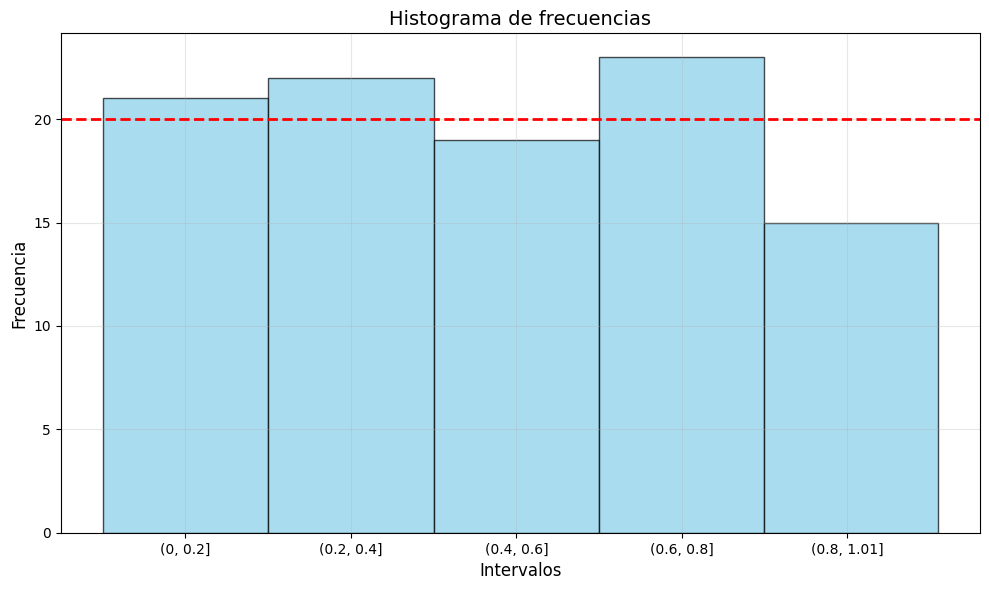

In [24]:
#Creamos lo que es la parte principal del hristograma, la gráfica
plt.figure(figsize=(10, 6))
plt.hist(lista, bins=bins, edgecolor='black', color='skyblue', alpha=0.7)

# Damos nombres a las etiquetas, creamos los intervalos en el histograma y le damos una malla en el fondo
plt.title('Histograma de frecuencias', fontsize=14)
plt.xlabel('Intervalos', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.axhline(y=20, color='red', linestyle='--', linewidth=2)
plt.xticks([0.1, 0.3, 0.5, 0.7, 0.9], intervalos)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()